In [1]:
pip install requests pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Data fetched for Chennai
Data fetched for Mumbai
Data fetched for Delhi
Data fetched for Bangalore
Data fetched for Hyderabad

Weather Data:
        City  Temperature (°C)  Humidity (%)  Wind Speed (km/h)
0    Chennai              36.2            42                6.5
1     Mumbai              33.2            60               15.3
2      Delhi              32.4            45                8.6
3  Bangalore              29.1            59               10.5
4  Hyderabad              34.7            37               15.7


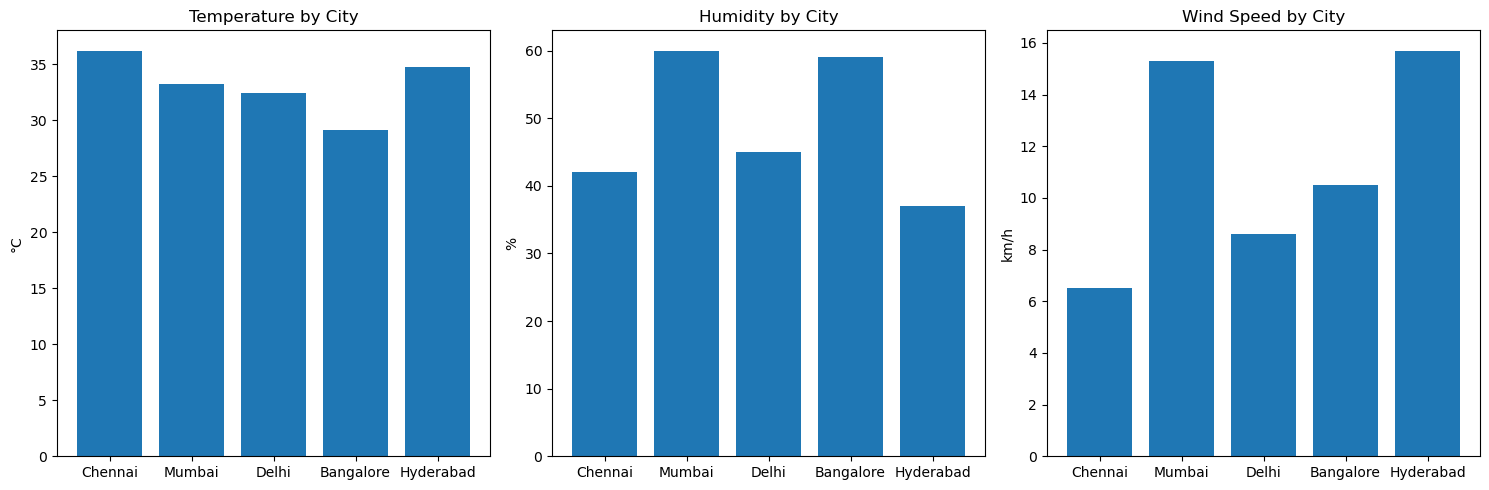


Files Generated Successfully:
1. weather_data.csv
2. weather_dashboard.png


In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Cities and coordinates
cities = {
    "Chennai": (13.0827, 80.2707),
    "Mumbai": (19.0760, 72.8777),
    "Delhi": (28.7041, 77.1025),
    "Bangalore": (12.9716, 77.5946),
    "Hyderabad": (17.3850, 78.4867)
}

weather_data = []

for city, (lat, lon) in cities.items():
    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&current=temperature_2m,relative_humidity_2m,wind_speed_10m"
    )

    response = requests.get(url)

    if response.status_code == 200:
        data = response.json()

        weather_data.append({
            "City": city,
            "Temperature (°C)": data["current"]["temperature_2m"],
            "Humidity (%)": data["current"]["relative_humidity_2m"],
            "Wind Speed (km/h)": data["current"]["wind_speed_10m"]
        })

        print(f"Data fetched for {city}")
    else:
        print(f"Failed to fetch data for {city}")

# Create DataFrame
weather_df = pd.DataFrame(weather_data)

print("\nWeather Data:")
print(weather_df)

# Save data to CSV
weather_df.to_csv("weather_data.csv", index=False)

# Create Dashboard
plt.figure(figsize=(15, 5))

# Temperature Chart
plt.subplot(1, 3, 1)
plt.bar(weather_df["City"], weather_df["Temperature (°C)"])
plt.title("Temperature by City")
plt.ylabel("°C")

# Humidity Chart
plt.subplot(1, 3, 2)
plt.bar(weather_df["City"], weather_df["Humidity (%)"])
plt.title("Humidity by City")
plt.ylabel("%")

# Wind Speed Chart
plt.subplot(1, 3, 3)
plt.bar(weather_df["City"], weather_df["Wind Speed (km/h)"])
plt.title("Wind Speed by City")
plt.ylabel("km/h")

plt.tight_layout()

# Save dashboard
plt.savefig("weather_dashboard.png")
plt.show()

print("\nFiles Generated Successfully:")
print("1. weather_data.csv")
print("2. weather_dashboard.png")
  
